<h1 style="text-align: center;">Trabajo Práctico N°4:</h1>
<h1 style="text-align: center;">Construcción y análisis de modelos de QSAR</h1>


## 🎯  Objetivos

* Aplicar los criterios de **Unger y Hansch** para construir, evaluar y seleccionar ecuaciones de QSAR.
* Aplicar herramientas estadísticas en modelos de regresión lineal simple y múltiple.
* Aprender a seleccionar descriptores relevantes en base a su correlación con la actividad biológica.
* Interpretar los coeficientes y métricas de ajuste del modelo (R², error estándar, etc.), y evaluar su capacidad predictiva.

## 🔍 Introducción a QSAR

El desarrollo racional de nuevos fármacos requiere cada vez más del uso de herramientas computacionales que permitan analizar, interpretar y predecir la actividad biológica de compuestos en función de su estructura química. Dentro de este marco, las **Relaciones Cuantitativas Estructura-Actividad** (QSAR, por sus siglas en inglés) constituyen una estrategia fundamental para correlacionar propiedades moleculares cuantificables con la eficacia o afinidad de una serie de compuestos frente a un blanco terapéutico común.

Para construir un modelo de QSAR confiable, es necesario contar con un conjunto de moléculas adecuadamente seleccionadas: deben compartir un mismo mecanismo de acción, actuar sobre el mismo receptor, tener actividades reportadas en condiciones experimentales comparables, y presentar una diversidad estructural razonable dentro de un marco común. Además, es imprescindible preparar los datos, evaluar sus distribuciones, normalizar sus escalas y seleccionar cuidadosamente los descriptores que formarán parte del modelo.

En este trabajo práctico, aplicaremos estos conceptos trabajando sobre un conjunto de agonistas que actúan sobre el receptor adrenérgico β2 que seleccionamos en el Seminario N°4. A través de diversas etapas, aprenderemos a construir modelos matemáticos que permitan correlacionar propiedades estructurales con la potencia biológica de los compuestos, evaluando el ajuste de dichos modelos y su utilidad predictiva. Para ello, aplicaremos las **reglas de Unger y Hansch**, que nos orientan sobre la forma, linealidad y relevancia de las variables utilizadas en modelos de este tipo.

## *Reglas de Unger y Hansch*

- 📊 <u>Selección de variables independientes</u>: los descriptores elegidos deben ser independientes entre sí; con coeficientes de correlación **intervariables** inferior a 0.6-0.7.
- ⚖️ <u>Justificación del número de términos o variables</u>: para evitar correlación casual y fortalecer la solidez estadśitica de los modelos, se debe contar con al menos **5-6 análogos por cada descriptor** o variable a incluir en el modelo final.
- 🔢 <u>Justificación de las variables independientes</u>: la mejor ecuación será aquella que presente mejores métricas estadísticas, siendo todos los coeficientes significativamente diferentes de cero.
- 🧘 <u>Principio de Parsimonia</u>: si las reglas anteriores se cumplen para más de un modelo, elegir el más simple.
- 🧠 <u>Modelo final con racionalidad cualitativa</u>: el modelo seleccionado, ¿puede ser explicado o relacionado con el caso en estudio?

## 🧪 **Actividades**
Los estudios de construcción y análisis de los modelos se encuentran previstos en 4 etapas secuenciales:

**1.** Construcción de un modelo de QSAR inicial con un *n* limitado.\
**2.** Construcción de un modelo de QSAR expandido.\
**3.** Construcción de un modelo de QSAR con más descriptores.\
**4.** Construcción de un modelo de QSAR expandido con más descriptores.

## **1.** Construcción de un modelo de QSAR inicial con un *n* limitado. 

En el Seminario N°4 seleccionamos un set conformado por 54 agonistas del receptor adrenérgico β2 reportados en la base de datos ChEMBL y en una patente. Les calculamos 5 descriptores (peso molecular, logP, cantidad de enlaces rotables y número de aceptores y donores de puente hidrógeno), y normalizamos los valores.\
Tomaremos inicialmente una muestra de esas moléculas para introducirnos en QSAR, y familiarizarnos con las reglas de Unger y Hansch.

In [3]:
from FuncionesTP4 import *

In [4]:
df_agonistas_B2 = pd.read_csv('df_b2_agonists_final_norm.csv') 
itables.show(df_agonistas_B2)

Loading ITables v2.8.0 from the init_notebook_mode cell... (need help?)


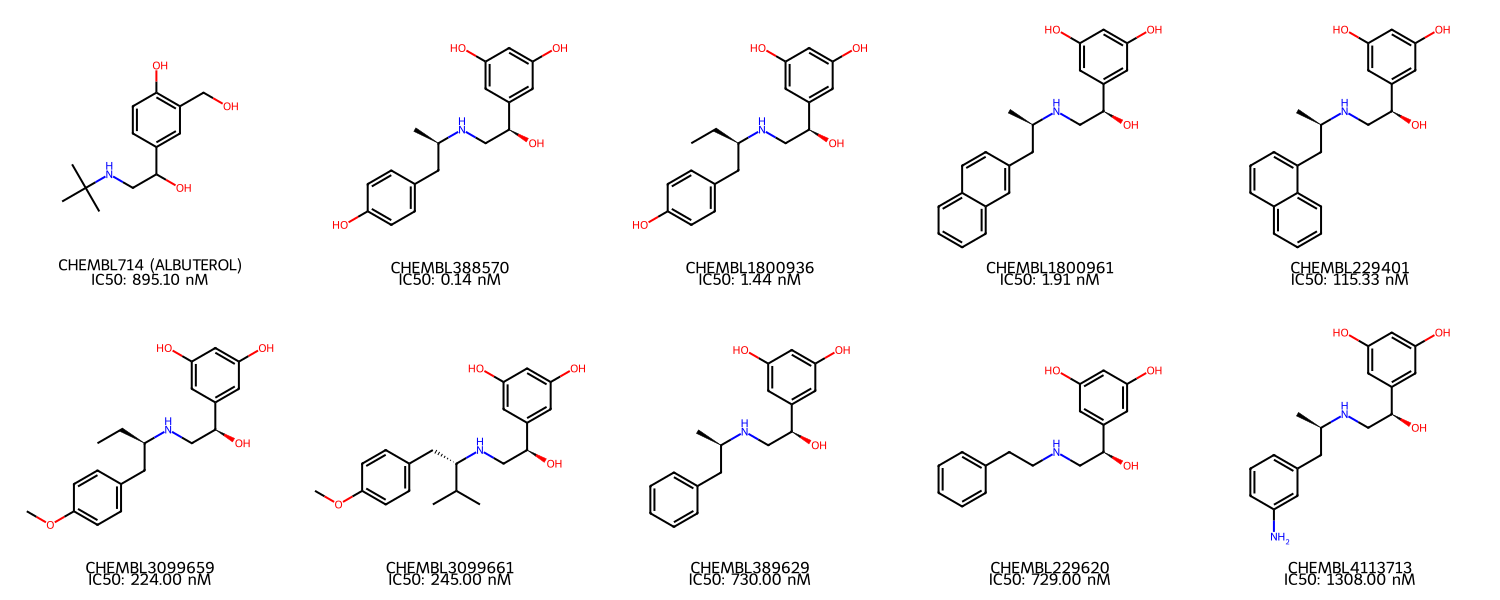

Loading ITables v2.8.0 from the init_notebook_mode cell... (need help?)


In [5]:
ids_primer_set = ['CHEMBL714', 'CHEMBL388570', 'CHEMBL1800936', 'CHEMBL1800961', 
                  'CHEMBL229401', 'CHEMBL3099659', 'CHEMBL3099661', 'CHEMBL389629', 'CHEMBL229620', 'CHEMBL4113713',]
Primer_set = df_agonistas_B2[df_agonistas_B2['molecule_chembl_id'].isin(ids_primer_set)]
mostrar_moleculas_por_id(Primer_set, ids_primer_set, grupo_funcional_smiles="CNCCO")

itables.show(Primer_set)

**Análisis de correlación intervariables**
\
El primer paso en el estudio estadístico es la realización del análisis de correlación intervariables, de manera de descartar los pares de descriptores que tengan una alta correlación entre sí (*regla 1: independencia de variables*).
\
Para ello, emplearemos una función que lo determinará automáticamente, y generará un mapa de calor (*heatmap*) con los valores de correlación indicados.

📌 Analice el resultado y seleccione los pares de variables que presenten una baja correlación entre sí para que puedan conformar una relación lineal múltiple de acuerdo a las reglas de Hunger-Hansh.

📌 ¿Son lógicos los resultados para aquellos pares de variables que presentan alta correlación? Justifique.

📌 ¿Es aconsejable obtener ecuaciones lineales multiparamétricas? Justifique.

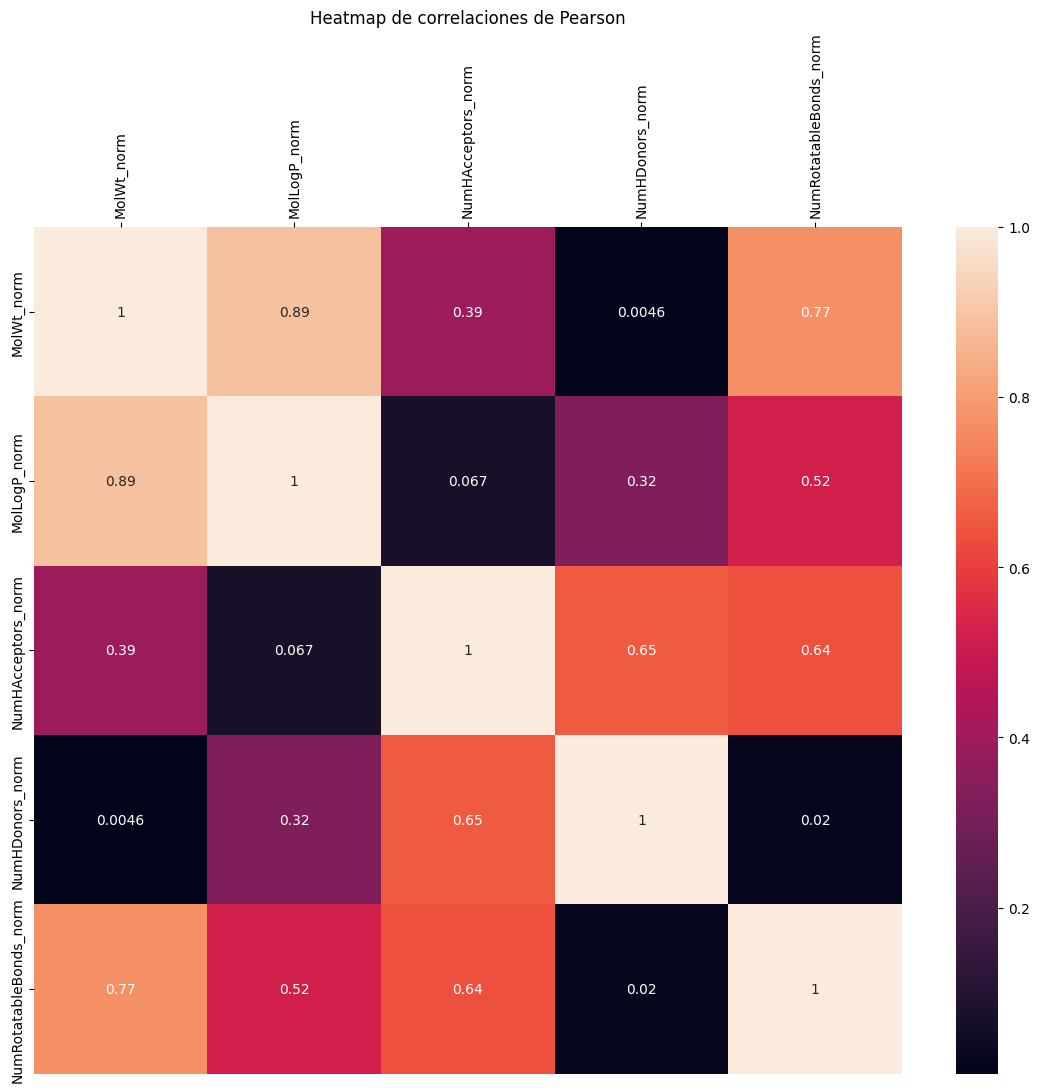

In [6]:
graficar_heatmap_pearson(Primer_set, columna_inicio='MolWt_norm')

**Confección de las ecuaciones lineales simples**

Analizaremos una por una todas las posibles ecuaciones lineales simples para extraer la información estadística necesaria que nos permita seleccionar el mejor modelo de QSAR del caso en estudio.

Ejecutando la siguiente función, podrán ver los gráficos de regresión, la tabla de resultados con todos los parámetros calculados, la ecuación correspondiente y el valor de R$^{2}$.

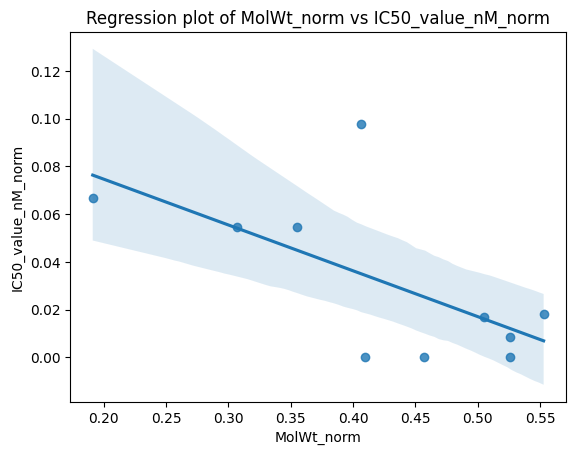

                            OLS Regression Results                            
Dep. Variable:     IC50_value_nM_norm   R-squared:                       0.412
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     5.615
Date:                Wed, 10 Jun 2026   Prob (F-statistic):             0.0453
Time:                        12:26:07   Log-Likelihood:                 22.742
No. Observations:                  10   AIC:                            -41.48
Df Residuals:                       8   BIC:                            -40.88
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1130      0.035      3.191      0.0

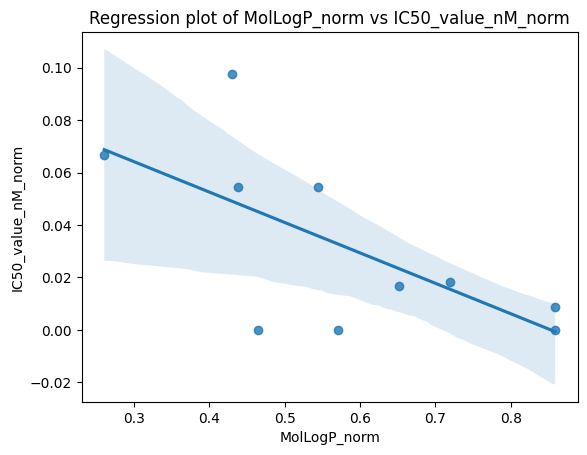

                            OLS Regression Results                            
Dep. Variable:     IC50_value_nM_norm   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     6.100
Date:                Wed, 10 Jun 2026   Prob (F-statistic):             0.0387
Time:                        12:26:07   Log-Likelihood:                 22.917
No. Observations:                  10   AIC:                            -41.83
Df Residuals:                       8   BIC:                            -41.23
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0990      0.029      3.464   

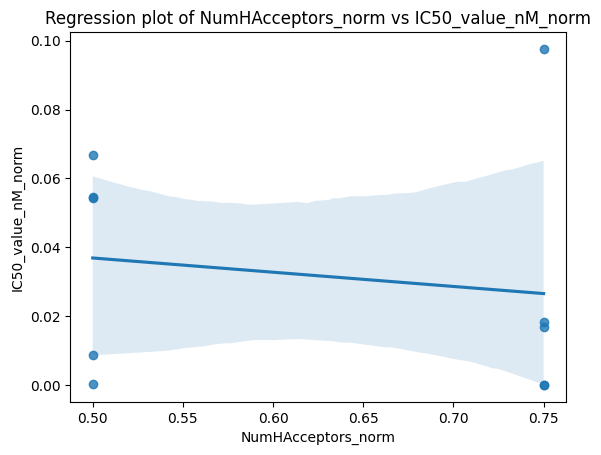

                            OLS Regression Results                            
Dep. Variable:     IC50_value_nM_norm   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                 -0.096
Method:                 Least Squares   F-statistic:                    0.2080
Date:                Wed, 10 Jun 2026   Prob (F-statistic):              0.660
Time:                        12:26:07   Log-Likelihood:                 20.212
No. Observations:                  10   AIC:                            -36.42
Df Residuals:                       8   BIC:                            -35.82
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0576      0

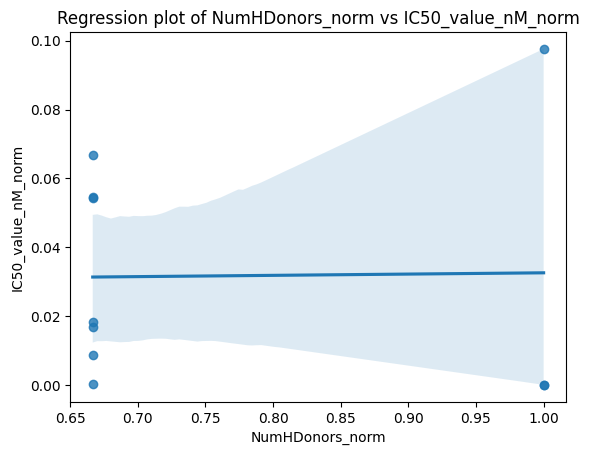

                            OLS Regression Results                            
Dep. Variable:     IC50_value_nM_norm   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.125
Method:                 Least Squares   F-statistic:                  0.002409
Date:                Wed, 10 Jun 2026   Prob (F-statistic):              0.962
Time:                        12:26:07   Log-Likelihood:                 20.085
No. Observations:                  10   AIC:                            -36.17
Df Residuals:                       8   BIC:                            -35.56
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0289      0.059     

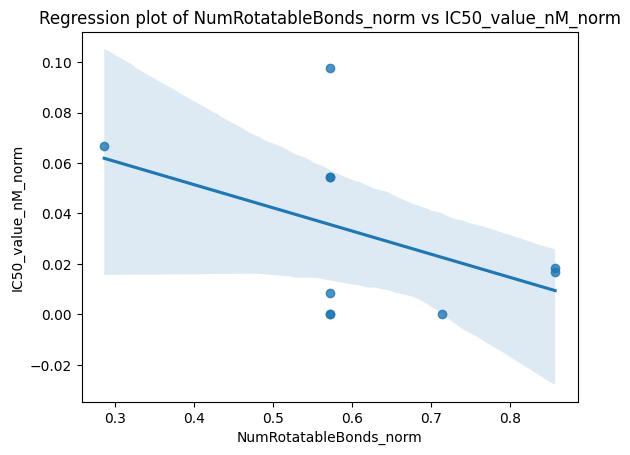

                            OLS Regression Results                            
Dep. Variable:     IC50_value_nM_norm   R-squared:                       0.197
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     1.965
Date:                Wed, 10 Jun 2026   Prob (F-statistic):              0.199
Time:                        12:26:07   Log-Likelihood:                 21.182
No. Observations:                  10   AIC:                            -38.36
Df Residuals:                       8   BIC:                            -37.76
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

Loading ITables v2.8.0 from the init_notebook_mode cell... (need help?)


In [7]:
descriptores = ['MolWt_norm', 'MolLogP_norm', 'NumHAcceptors_norm', 'NumHDonors_norm', 'NumRotatableBonds_norm']
resultados = analizar_regresiones_lineales_simples(Primer_set, 'IC50_value_nM_norm', descriptores)
resultados

En base a los resultados:

📌 Identifique y plantee la equación con mayor potencial predictivo, y que cumpla con las cuatro primeras reglas de Unger y Hansch. 

📌 Teniendo en cuenta la información provista respecto del modo de acción los agonistas del receptor adrenérgico β2, analice si los resultados del modelo de QSAR obtenidos son cualitativamente razonables.

## **2.** Construcción de un modelo de QSAR expandido.

Hemos identificado que usar un número reducido de moléculas, y consecuentemente solo plantear modelos simples o de descriptores únicos, no es una estrategia racional.
Por lo tanto, ahora emplearemos un set expandido de agonistas, incluyendo solamente aquellos 39 que extrajimos originalmente de ChEMBL. 

In [8]:
df_agonistas_B2_expandido = pd.read_csv('df_b2_agonists_final_norm.csv').head(39)
df_agonistas_B2_expandido

Loading ITables v2.8.0 from the init_notebook_mode cell... (need help?)


De la misma manera que se ha realizado en la sección anterior y siguiendo las reglas de Unger y Hansch, utilizaremos el conjunto de datos extendidos para construir un nuevo modelo de QSAR, identificando la ecuación con mayor potencial predictivo.

📌 Analice el mapa de correlaciones para el nuevo set de compuestos. ¿Hubo algún cambio respecto al set anterior? 

📌 ¿Es aconsejable obtener ecuaciones lineales multiparamétricas? Justifique.

📌 Seleccione los pares de variables que presenten una baja correlación entre sí para que puedan conformar una relación lineal múltiple de acuerdo a las reglas de Hunger-Hansh.

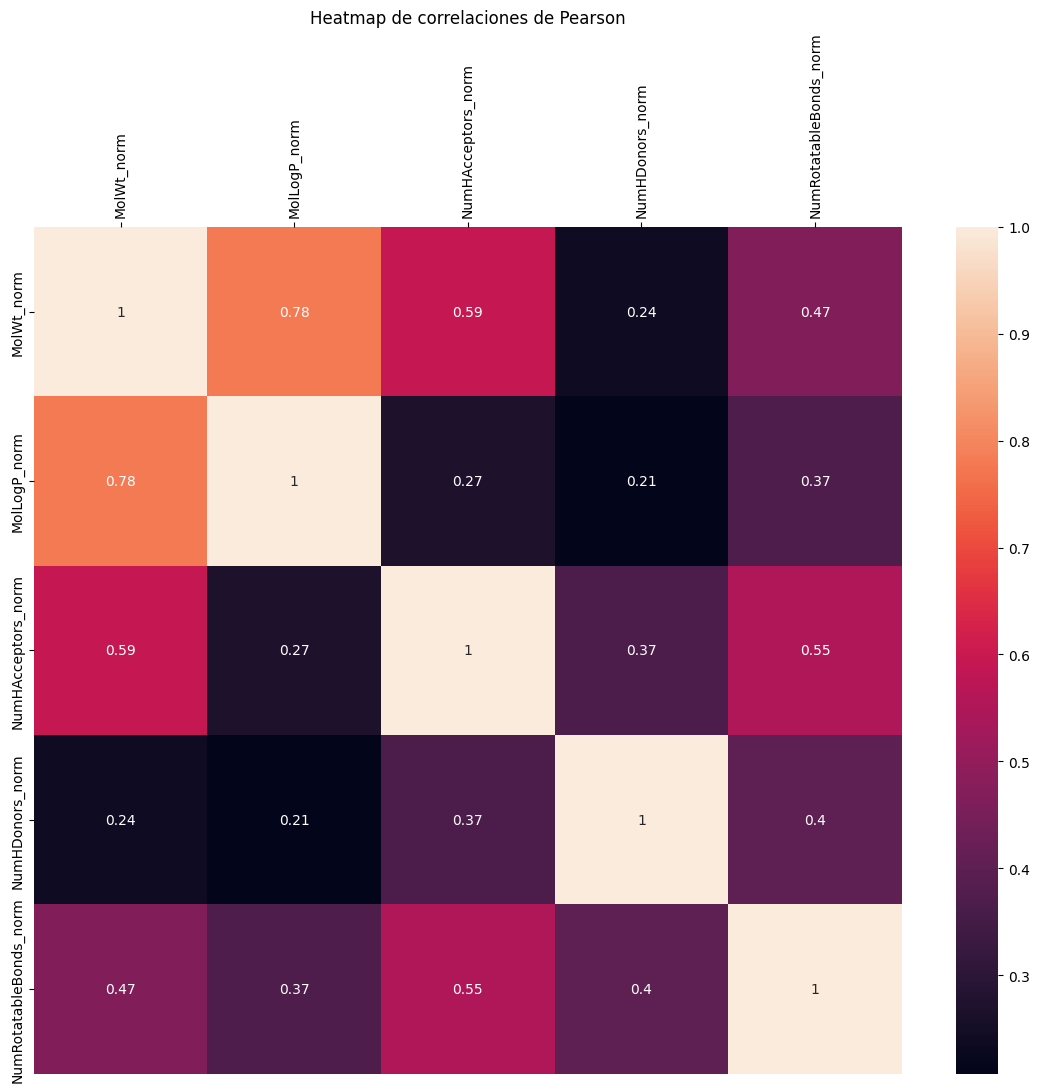

In [9]:
graficar_heatmap_pearson(df_agonistas_B2_expandido, columna_inicio='MolWt_norm')

Cuando aumenta el número de moléculas y, consecuentemente, las combinaciones de descriptores que pueden combinarse en modelos multiparamétricos, el análisis de correlación puede complicarse.
Por lo tanto, la siguiente función permite identificar y generar automáticamente todas las combinaciones posibles de ecuaciones lineales simples y multiparamétricas. 

Ejecútenla y verifiquen el resultado que analizaron anteriormente.

In [10]:
descriptores = ['MolWt_norm', 'MolLogP_norm', 'NumHAcceptors_norm', 'NumHDonors_norm', 'NumRotatableBonds_norm']
combis_validas = obtener_combinaciones_validas(df_agonistas_B2_expandido, descriptores)

print(f"Se encontraron {len(combis_validas)} combinaciones válidas:")
for c in combis_validas:
    print(c)

Se encontraron 23 combinaciones válidas:
('MolWt_norm',)
('MolLogP_norm',)
('NumHAcceptors_norm',)
('NumHDonors_norm',)
('NumRotatableBonds_norm',)
('MolWt_norm', 'NumHAcceptors_norm')
('MolWt_norm', 'NumHDonors_norm')
('MolWt_norm', 'NumRotatableBonds_norm')
('MolLogP_norm', 'NumHAcceptors_norm')
('MolLogP_norm', 'NumHDonors_norm')
('MolLogP_norm', 'NumRotatableBonds_norm')
('NumHAcceptors_norm', 'NumHDonors_norm')
('NumHAcceptors_norm', 'NumRotatableBonds_norm')
('NumHDonors_norm', 'NumRotatableBonds_norm')
('MolWt_norm', 'NumHAcceptors_norm', 'NumHDonors_norm')
('MolWt_norm', 'NumHAcceptors_norm', 'NumRotatableBonds_norm')
('MolWt_norm', 'NumHDonors_norm', 'NumRotatableBonds_norm')
('MolLogP_norm', 'NumHAcceptors_norm', 'NumHDonors_norm')
('MolLogP_norm', 'NumHAcceptors_norm', 'NumRotatableBonds_norm')
('MolLogP_norm', 'NumHDonors_norm', 'NumRotatableBonds_norm')
('NumHAcceptors_norm', 'NumHDonors_norm', 'NumRotatableBonds_norm')
('MolWt_norm', 'NumHAcceptors_norm', 'NumHDonors_norm

In [11]:
df_qsar = evaluar_modelos_qsar(df_agonistas_B2_expandido, descriptores, y_col='IC50_value_nM_norm')
itables.show(df_qsar)

Loading ITables v2.8.0 from the init_notebook_mode cell... (need help?)


En base a los resultados:

📌 Identifique y plantee la equación con mayor potencial predictivo, y que cumpla con las cuatro primeras reglas de Unger y Hansch. 

📌 Teniendo en cuenta la información provista respecto del modo de acción los agonistas del receptor adrenérgico β2, analice si los resultados del modelo de QSAR obtenidos son cualitativamente razonables.

## **3.** Construcción de un modelo de QSAR con más descriptores.

Tal como aprendieron en los teóricos de QSAR, existe una gran diversidad de descriptores moleculares.

En este sentido, calcularemos ahora nuevos descriptores para el set de agonistas, y repetiremos todo el análisis para intentar identificar un mejor modelo de QSAR.

In [12]:
nuevos_descriptores = ['MolWtSinH', 'CargaMax', 'CargaMin', 'DensidadEstructural', 'IndiceComplejidad',
                       'AreaAccesibleSolvente', 'RefractividadMol', 'SuperficieElectronegativa', 'SuperficieHidrofobica',
                       'AreaSuperficial', 'AreaRefractiva', 'DistribucionElectronica', 'TPSA']

df_con_descriptores = agregar_descriptores(df_agonistas_B2_expandido, seleccion=nuevos_descriptores, antes_de_columna='IC50_value_nM_norm')
itables.show(df_con_descriptores)

Loading ITables v2.8.0 from the init_notebook_mode cell... (need help?)


Recuerden que es importante normalizar los datos, tal como hicimos con los descriptores de Lipinski.

In [13]:
df_agonistas_B2_mas_desc = normalizar_columnas_seleccionadas(df_con_descriptores, nuevos_descriptores)
itables.show(df_agonistas_B2_mas_desc)

Loading ITables v2.8.0 from the init_notebook_mode cell... (need help?)


📌 Realice el análisis de correlación y determine todas las ecuaciones posibles.

Luego, en base a los resultados:

📌 Identifique y plantee la equación con mayor potencial predictivo, y que cumpla con las cuatro primeras reglas de Unger y Hansch. 

📌 Analice si los resultados del modelo de QSAR obtenidos son cualitativamente razonables, teniendo en cuenta la información provista respecto del modo de acción los agonistas del receptor adrenérgico β2,

📌 Explique los detalles que diferencian a los modelos construidos en las tres actividades, indicando cuál de ellos considera que presenta el mayor potencial predictivo.

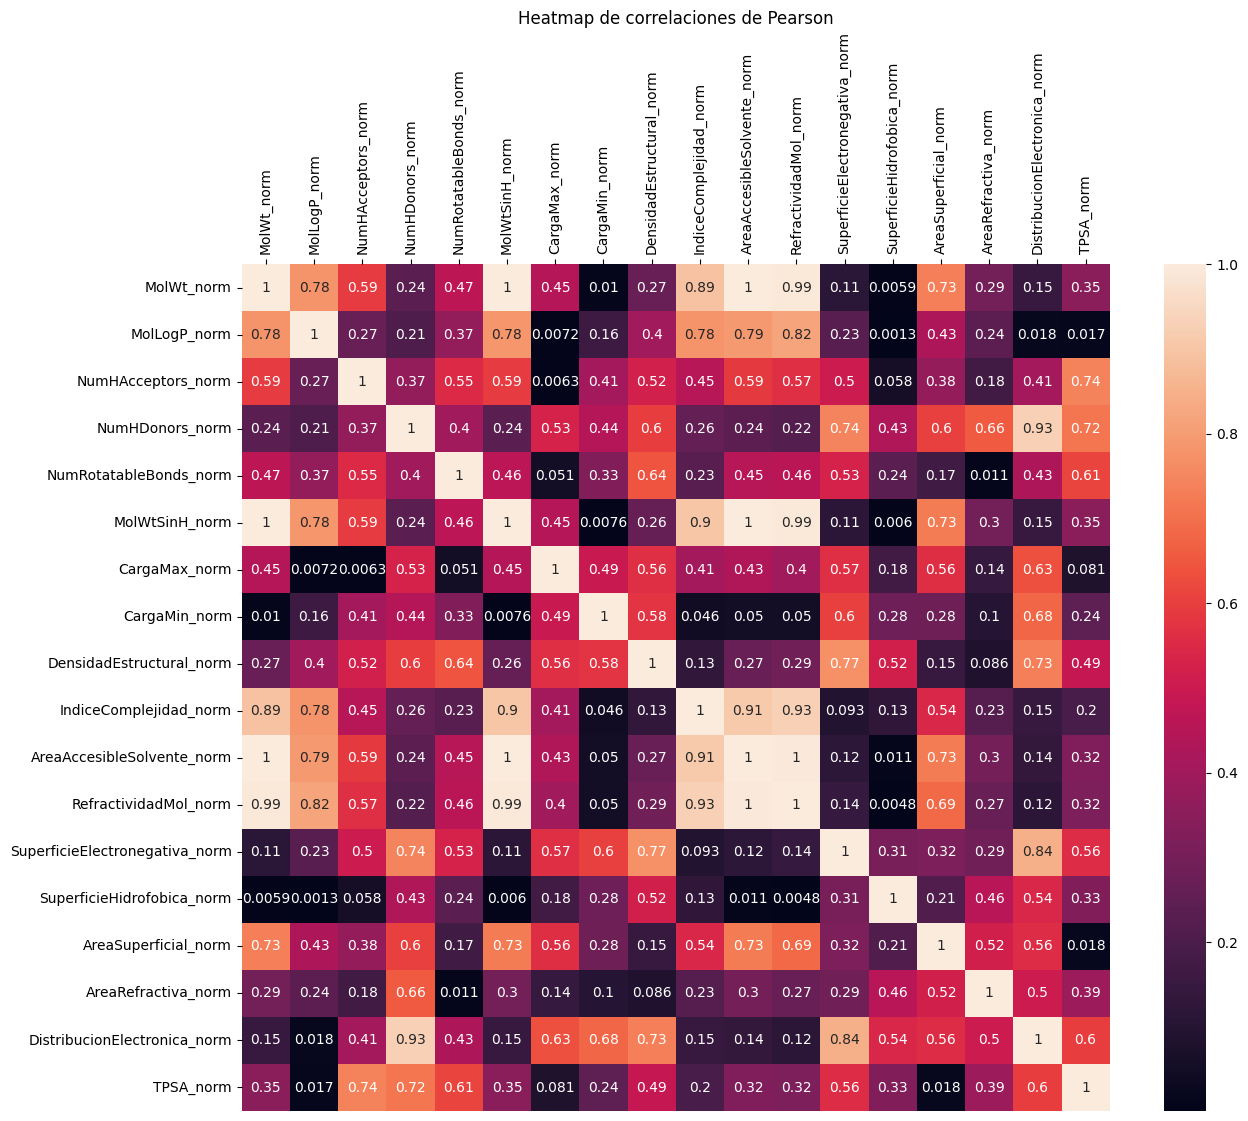

In [14]:
graficar_heatmap_pearson(df_agonistas_B2_mas_desc, columna_inicio='MolWt_norm')

In [15]:
descriptores_nuevos = ['MolWtSinH_norm', 'CargaMax_norm', 'CargaMin_norm', 'DensidadEstructural_norm', 'IndiceComplejidad_norm',
                       'AreaAccesibleSolvente_norm', 'RefractividadMol_norm', 'SuperficieElectronegativa_norm', 'SuperficieHidrofobica_norm',
                       'AreaSuperficial_norm', 'AreaRefractiva_norm', 'DistribucionElectronica_norm', 'TPSA_norm', 
                       'MolWt_norm', 'NumHAcceptors_norm', 'NumHDonors_norm', 'MolLogP_norm', 'NumRotatableBonds_norm']

combis_validas = obtener_combinaciones_validas(df_agonistas_B2_mas_desc, descriptores_nuevos)

print(f"Se encontraron {len(combis_validas)} combinaciones válidas!")

Se encontraron 2121 combinaciones válidas!


In [16]:
df_qsar_new = evaluar_modelos_qsar(df_agonistas_B2_mas_desc, descriptores_nuevos, y_col='IC50_value_nM_norm')
itables.show(df_qsar_new)

Loading ITables v2.8.0 from the init_notebook_mode cell... (need help?)


## **4.** Construcción de un modelo de QSAR expandido con más descriptores.

En el Seminario N°4, tras un análisis bibliográfico, agregamos 15 agonistas β₂ extraidos de una patente farmacéutica, que poseían gran semejanza estructural con las 39 moléculas previamente extraídas de ChEMBL. Si el modelo de QSAR seleccionado es suficientemente robusto, la inclusión de estas moléculas no debería modificar significativamente el resultado final. ¡Corroborémoslo!

In [18]:
df_agonistas_B2_expandido_final = pd.read_csv('df_b2_agonists_final_norm.csv') 
df_agonistas_B2_expandido_final_desc = agregar_descriptores(df_agonistas_B2_expandido_final, seleccion=nuevos_descriptores, antes_de_columna='IC50_value_nM_norm')
df_agonistas_B2_expandido_final_desc = normalizar_columnas_seleccionadas(df_agonistas_B2_expandido_final_desc, nuevos_descriptores)

itables.show(df_agonistas_B2_expandido_final_desc)

Loading ITables v2.8.0 from the init_notebook_mode cell... (need help?)


In [19]:
combis_validas = obtener_combinaciones_validas(df_agonistas_B2_expandido_final_desc, descriptores_nuevos)

print(f"Se encontraron {len(combis_validas)} combinaciones válidas!")

Se encontraron 2626 combinaciones válidas!


In [20]:
df_qsar_new = evaluar_modelos_qsar(df_agonistas_B2_expandido_final_desc, descriptores_nuevos, y_col='IC50_value_nM_norm')
itables.show(df_qsar_new)

Loading ITables v2.8.0 from the init_notebook_mode cell... (need help?)
